# GridWorld — Value Iteration vs. Q-Learning

A 5×5 GridWorld with a goal, a hazard, and a step cost, solved two ways: **Value Iteration** (which
knows the full model — the reward function and transition dynamics — and computes the optimal policy
directly via the Bellman optimality backup) and **Q-Learning** (which learns purely from
trial-and-error experience, with no access to the model). The two learned policies are then compared
directly.

## Step 1: Define the GridWorld

In [1]:
import numpy as np


In [2]:
grid_size = 5
rewards = np.full((grid_size, grid_size), -1.0)  # default: -1 everywhere (step cost)

goal_pos = (4, 4)
hazard_pos = (2, 2)

rewards[goal_pos] = 10.0
rewards[hazard_pos] = -10.0

terminal_states = {goal_pos, hazard_pos}

actions = {
    "up":    (-1, 0),
    "down":  (1, 0),
    "left":  (0, -1),
    "right": (0, 1),
}


In [3]:
print(rewards)
print(terminal_states)


[[ -1.  -1.  -1.  -1.  -1.]
 [ -1.  -1.  -1.  -1.  -1.]
 [ -1.  -1. -10.  -1.  -1.]
 [ -1.  -1.  -1.  -1.  -1.]
 [ -1.  -1.  -1.  -1.  10.]]
{(4, 4), (2, 2)}


In [4]:
def get_next_state(state, action, grid_size):
    """Applies an action, clamping at grid edges (bumping a wall leaves the agent in place)."""
    row, col = state
    d_row, d_col = actions[action]

    new_row = row + d_row
    new_col = col + d_col

    if new_row < 0:
        new_row = 0
    elif new_row >= grid_size:
        new_row = grid_size - 1

    if new_col < 0:
        new_col = 0
    elif new_col >= grid_size:
        new_col = grid_size - 1

    return (new_row, new_col)


In [5]:
print(get_next_state((0, 0), "up", grid_size))     # should stay (0,0) — can't go further up
print(get_next_state((2, 2), "right", grid_size))  # should become (2,3)
print(get_next_state((4, 4), "down", grid_size))   # should stay (4,4) — can't go further down


(0, 0)
(2, 3)
(4, 4)


## Value Iteration

Repeatedly applies the Bellman optimality backup $V(s) \leftarrow \max_a \left[ R(s') + \gamma V(s') \right]$
(with $s'$ the state reached from $s$ by action $a$) until $V$ stops changing, then extracts the greedy
policy with respect to the converged $V$. This requires knowing the reward function and transition
dynamics up front — the agent never actually has to act in the environment.

In [6]:
def value_iteration_sweep(V, rewards, terminal_states, actions, grid_size, gamma=0.9):
    """One synchronous Bellman-optimality backup over every non-terminal state."""
    new_V = V.copy()

    for row in range(grid_size):
        for col in range(grid_size):
            state = (row, col)
            if state in terminal_states:
                new_V[state] = 0
                continue

            action_values = []
            for action in actions:
                next_state = get_next_state(state, action, grid_size)
                reward = rewards[next_state]

                value_s = reward + gamma * V[next_state]
                action_values.append(value_s)

            new_V[state] = max(action_values)

    return new_V


In [7]:
V = np.zeros((grid_size, grid_size))
V = value_iteration_sweep(V, rewards, terminal_states, actions, grid_size)
V = value_iteration_sweep(V, rewards, terminal_states, actions, grid_size)

print(V)


[[-1.9 -1.9 -1.9 -1.9 -1.9]
 [-1.9 -1.9 -1.9 -1.9 -1.9]
 [-1.9 -1.9  0.  -1.9  8. ]
 [-1.9 -1.9 -1.9  8.  10. ]
 [-1.9 -1.9  8.  10.   0. ]]


In [8]:
V = np.zeros((grid_size, grid_size))
for i in range(100):
    new_V = value_iteration_sweep(V, rewards, terminal_states, actions, grid_size)
    diff = np.max(np.abs(new_V - V))
    V = new_V
    if diff < 0.001:
        print(f"Converged after {i + 1} sweeps")
        break

print(V)


Converged after 9 sweeps
[[-0.434062  0.62882   1.8098    3.122     4.58    ]
 [ 0.62882   1.8098    3.122     4.58      6.2     ]
 [ 1.8098    3.122     0.        6.2       8.      ]
 [ 3.122     4.58      6.2       8.       10.      ]
 [ 4.58      6.2       8.       10.        0.      ]]


In [9]:
def extract_policy(V, rewards, terminal_states, actions, grid_size, gamma=0.9):
    """Greedy policy with respect to a converged value function V."""
    policy = {}

    for row in range(grid_size):
        for col in range(grid_size):
            state = (row, col)
            if state in terminal_states:
                continue

            best_action = None
            best_value = -np.inf

            for action in actions:
                next_state = get_next_state(state, action, grid_size)
                value = rewards[next_state] + gamma * V[next_state]
                if value > best_value:
                    best_value = value
                    best_action = action

            policy[state] = best_action

    return policy


In [10]:
policy = extract_policy(V, rewards, terminal_states, actions, grid_size)
print(policy)


{(0, 0): 'down', (0, 1): 'down', (0, 2): 'down', (0, 3): 'down', (0, 4): 'down', (1, 0): 'down', (1, 1): 'down', (1, 2): 'right', (1, 3): 'down', (1, 4): 'down', (2, 0): 'down', (2, 1): 'down', (2, 3): 'down', (2, 4): 'down', (3, 0): 'down', (3, 1): 'down', (3, 2): 'down', (3, 3): 'down', (3, 4): 'down', (4, 0): 'right', (4, 1): 'right', (4, 2): 'right', (4, 3): 'right'}


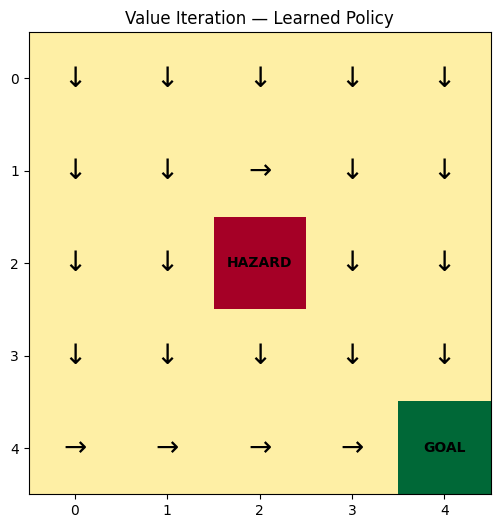

In [11]:
import matplotlib.pyplot as plt

action_arrows = {
    "up": "↑",
    "down": "↓",
    "left": "←",
    "right": "→",
}

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rewards, cmap="RdYlGn", vmin=-10, vmax=10)

for state, action in policy.items():
    row, col = state
    ax.text(col, row, action_arrows[action], ha="center", va="center", fontsize=20)

for state in terminal_states:
    row, col = state
    label = "GOAL" if rewards[state] > 0 else "HAZARD"
    ax.text(col, row, label, ha="center", va="center", fontsize=10, color="black", weight="bold")

ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))
plt.title("Value Iteration — Learned Policy")
plt.show()


## Q-Learning

An off-policy, model-free TD control algorithm: the agent only ever sees $(s, a, r, s')$ transitions
from actually acting in the environment (with an $\varepsilon$-greedy exploration policy), and updates
$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$ after every step —
no model of the rewards or transitions is ever given to it directly.

In [12]:
q_table = np.zeros((grid_size, grid_size, 4))
action_list = list(actions.keys())  # ["up", "down", "left", "right"], fixed order


In [13]:
def select_action_q(state, q_table, epsilon, action_list):
    """Epsilon-greedy action selection over the Q-table."""
    row, col = state
    a = np.random.random()

    if a < epsilon:
        return np.random.choice(action_list)
    else:
        q_values = q_table[row, col, :]
        best_index = np.argmax(q_values)
        return action_list[best_index]


In [14]:
action = select_action_q((0, 0), q_table, 1.0, action_list)
print(action)  # with epsilon=1.0, should be random each time


right


In [15]:
for _ in range(5):
    print(select_action_q((0, 0), q_table, 0.0, action_list))


up
up
up
up
up


In [16]:
def update_q(q_table, state, action, reward, next_state, action_list, learning_rate=0.1, gamma=0.9):
    """One Q-learning update (off-policy TD target using max over next-state Q-values)."""
    row, col = state
    next_row, next_col = next_state
    action_idx = action_list.index(action)

    current_q = q_table[row, col, action_idx]
    max_next_q = np.max(q_table[next_row, next_col, :])

    target = reward + gamma * max_next_q
    q_table[row, col, action_idx] = current_q + learning_rate * (target - current_q)

    return q_table


In [17]:
q_table = np.zeros((grid_size, grid_size, 4))

# pretend the agent was at (3,4), took action "down", landed on goal (4,4), got reward 10
q_table = update_q(q_table, (3, 4), "down", 10, (4, 4), action_list)

print(q_table[3, 4, :])  # should show a nonzero value at the "down" index, others still 0


[0. 1. 0. 0.]


In [18]:
q_table = np.zeros((grid_size, grid_size, 4))
start_state = (0, 0)

num_episodes = 500
epsilon = 1.0
epsilon_decay = 0.995
epsilon_min = 0.05

for episode in range(num_episodes):
    state = start_state
    done = False
    steps = 0

    while not done and steps < 100:  # cap steps to avoid infinite loops early on
        action = select_action_q(state, q_table, epsilon, action_list)
        next_state = get_next_state(state, action, grid_size)
        reward = rewards[next_state]

        q_table = update_q(q_table, state, action, reward, next_state, action_list)

        state = next_state
        steps += 1

        if state in terminal_states:
            done = True

    epsilon = max(epsilon_min, epsilon * epsilon_decay)


In [19]:
def extract_policy_q(q_table, terminal_states, action_list, grid_size):
    """Greedy policy with respect to the learned Q-table."""
    policy = {}

    for row in range(grid_size):
        for col in range(grid_size):
            state = (row, col)
            if state in terminal_states:
                continue

            q_values = q_table[row, col, :]
            best_idx = np.argmax(q_values)
            policy[state] = action_list[best_idx]

    return policy


In [20]:
policy_q = extract_policy_q(q_table, terminal_states, action_list, grid_size)
print(policy_q)


{(0, 0): 'down', (0, 1): 'down', (0, 2): 'down', (0, 3): 'down', (0, 4): 'down', (1, 0): 'down', (1, 1): 'down', (1, 2): 'right', (1, 3): 'down', (1, 4): 'down', (2, 0): 'right', (2, 1): 'down', (2, 3): 'down', (2, 4): 'down', (3, 0): 'right', (3, 1): 'down', (3, 2): 'down', (3, 3): 'down', (3, 4): 'down', (4, 0): 'right', (4, 1): 'right', (4, 2): 'right', (4, 3): 'right'}


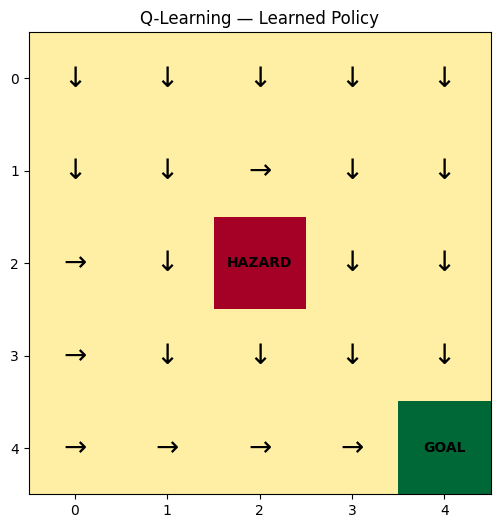

In [21]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(rewards, cmap="RdYlGn", vmin=-10, vmax=10)

for state, action in policy_q.items():
    row, col = state
    ax.text(col, row, action_arrows[action], ha="center", va="center", fontsize=20)

for state in terminal_states:
    row, col = state
    label = "GOAL" if rewards[state] > 0 else "HAZARD"
    ax.text(col, row, label, ha="center", va="center", fontsize=10, color="black", weight="bold")

ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))
plt.title("Q-Learning — Learned Policy")
plt.show()


## Comparison

Value Iteration gets the exact optimal policy immediately, since it has the full model. Q-Learning has
to discover the same thing purely from 500 episodes of trial and error, with no access to the reward
function or transition dynamics — so exact agreement between the two isn't guaranteed (ties between
equally-good actions can be broken differently), but they should agree almost everywhere.

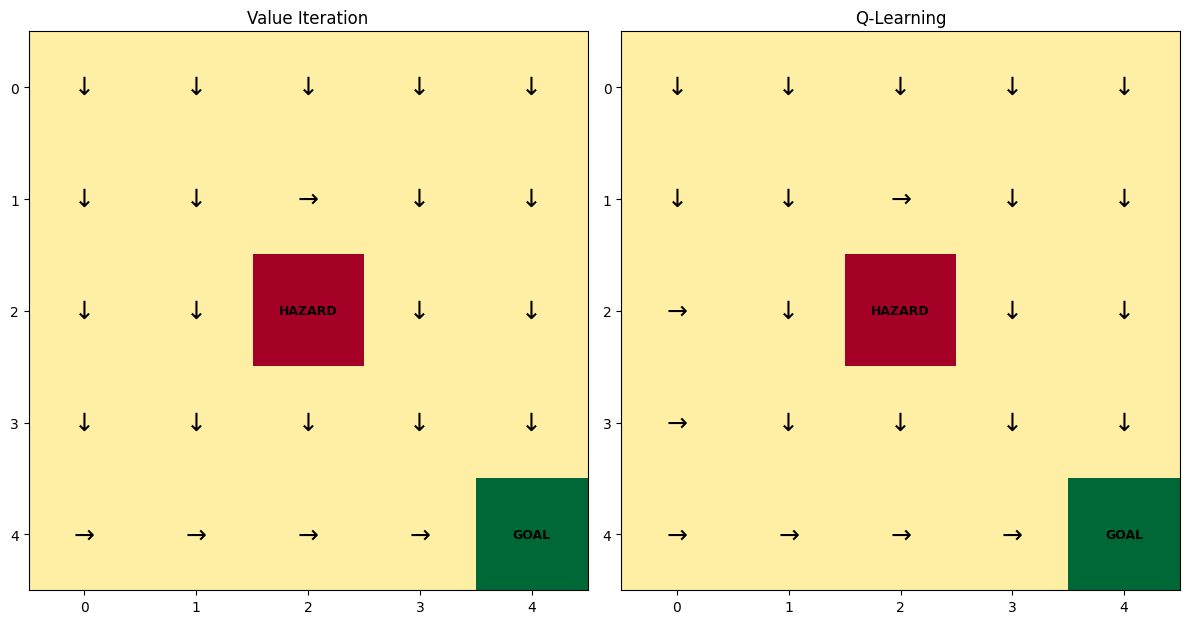

Policies agree on 21/23 states (91%)


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, (title, pol) in zip(axes, [("Value Iteration", policy), ("Q-Learning", policy_q)]):
    ax.imshow(rewards, cmap="RdYlGn", vmin=-10, vmax=10)
    for state, action in pol.items():
        row, col = state
        ax.text(col, row, action_arrows[action], ha="center", va="center", fontsize=18)
    for state in terminal_states:
        row, col = state
        label = "GOAL" if rewards[state] > 0 else "HAZARD"
        ax.text(col, row, label, ha="center", va="center", fontsize=9, weight="bold")
    ax.set_title(title)
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))

plt.tight_layout()
plt.show()

agreement = sum(policy[s] == policy_q[s] for s in policy)
print(f"Policies agree on {agreement}/{len(policy)} states ({100 * agreement / len(policy):.0f}%)")


## Convergence Over Episodes

A separate training run (same setup) tracking total episode reward, to see how Q-Learning's
performance improves as $\varepsilon$ decays and the Q-table converges.

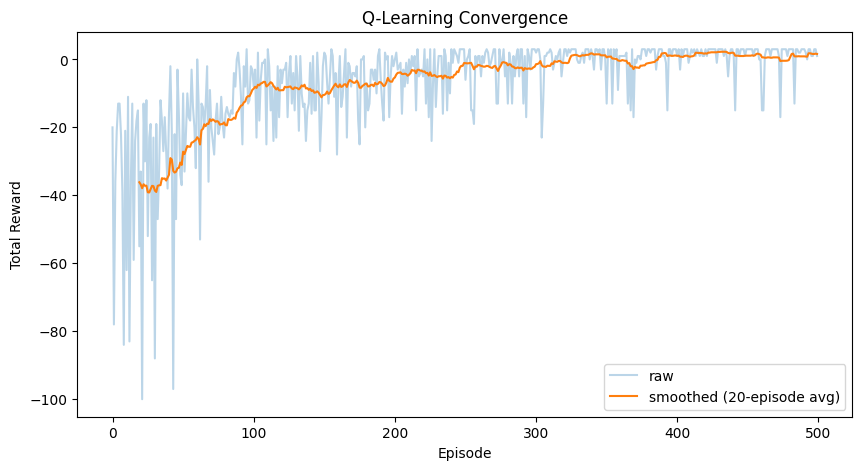

In [23]:
q_table = np.zeros((grid_size, grid_size, 4))
epsilon = 1.0
episode_rewards = []

for episode in range(num_episodes):
    state = start_state
    done = False
    steps = 0
    total_reward = 0

    while not done and steps < 100:
        action = select_action_q(state, q_table, epsilon, action_list)
        next_state = get_next_state(state, action, grid_size)
        reward = rewards[next_state]

        q_table = update_q(q_table, state, action, reward, next_state, action_list)

        state = next_state
        total_reward += reward
        steps += 1

        if state in terminal_states:
            done = True

    episode_rewards.append(total_reward)
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

plt.figure(figsize=(10, 5))
plt.plot(episode_rewards, alpha=0.3, label="raw")
window = 20
smoothed = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")
plt.plot(range(window - 1, len(episode_rewards)), smoothed, label=f"smoothed ({window}-episode avg)")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Q-Learning Convergence")
plt.legend()
plt.show()
